In [3]:
!pip install -q timm h5py scikit-learn torch torchvision

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import json

# Paste your token here
KAGGLE_TOKEN = "KGAT_9baa6a07ee3bfca44afa48321f1ac5a9"  # replace with yours if different
KAGGLE_USERNAME = "shrirakshasrinivas"                 # <-- put your Kaggle username here

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

kaggle_json = {"username": KAGGLE_USERNAME, "key": KAGGLE_TOKEN}

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_json, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("kaggle.json created successfully!")

kaggle.json created successfully!


In [6]:
!kaggle datasets download -d awsaf49/brats2020-training-data -p /content/brats2020
!unzip -q /content/brats2020/brats2020-training-data.zip -d /content/brats2020/

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats2020-training-data
License(s): CC0-1.0
100% 6.76G/6.76G [02:50<00:00, 42.5MB/s]



In [7]:
!ls /content/brats2020/
!ls /content/brats2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/ | head -5

 BraTS2020_training_data      'BraTS20 Training Metadata.csv'
 brats2020-training-data.zip
ls: cannot access '/content/brats2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/': No such file or directory


In [8]:
!ls /content/brats2020/BraTS2020_training_data/ | head -10

content


In [9]:
!ls /content/brats2020/BraTS2020_training_data/content/ | head -10

data


In [10]:
!ls /content/brats2020/BraTS2020_training_data/content/data/ | head -10

meta_data.csv
name_mapping.csv
survival_info.csv
volume_100_slice_0.h5
volume_100_slice_100.h5
volume_100_slice_101.h5
volume_100_slice_102.h5
volume_100_slice_103.h5
volume_100_slice_104.h5
volume_100_slice_105.h5


In [11]:
import pandas as pd

DATA_DIR = "/content/brats2020/BraTS2020_training_data/content/data"

meta = pd.read_csv(f"{DATA_DIR}/meta_data.csv")
print(meta.shape)
print(meta.head(10))
print(meta.columns.tolist())

(57195, 4)
                           slice_path  target  volume  slice
0  /content/data/volume_41_slice_0.h5       0      41      0
1  /content/data/volume_41_slice_1.h5       0      41      1
2  /content/data/volume_41_slice_2.h5       0      41      2
3  /content/data/volume_41_slice_3.h5       0      41      3
4  /content/data/volume_41_slice_4.h5       0      41      4
5  /content/data/volume_41_slice_5.h5       0      41      5
6  /content/data/volume_41_slice_6.h5       0      41      6
7  /content/data/volume_41_slice_7.h5       0      41      7
8  /content/data/volume_41_slice_8.h5       0      41      8
9  /content/data/volume_41_slice_9.h5       0      41      9
['slice_path', 'target', 'volume', 'slice']


In [12]:
import h5py

# Check what's inside one h5 file
sample_path = f"{DATA_DIR}/volume_41_slice_0.h5"
with h5py.File(sample_path, 'r') as f:
    print("Keys:", list(f.keys()))
    for k in f.keys():
        print(f"  {k}: shape={f[k].shape}, dtype={f[k].dtype}")

Keys: ['image', 'mask']
  image: shape=(240, 240, 4), dtype=float64
  mask: shape=(240, 240, 3), dtype=uint8


In [13]:
import os
import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    log_loss, accuracy_score, precision_score, recall_score, f1_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

DATA_DIR = "/content/brats2020/BraTS2020_training_data/content/data"
CLASS_NAMES = ['NCR', 'ED', 'ET']

Using device: cuda


In [14]:
meta = pd.read_csv(f"{DATA_DIR}/meta_data.csv")
print(f"Total slices: {len(meta)}")
print(f"Unique volumes (patients): {meta['volume'].nunique()}")

# For each patient, scan slices and check if each tumor sub-region is present
# We read a sample of slices per patient to build labels
# mask shape: (240, 240, 3) -> channels are [NCR, ED, ET]

def get_patient_labels(meta, data_dir, sample_every=5):
    """
    Build patient-level [NCR, ED, ET] binary labels.
    To save time, we sample every Nth slice per patient.
    """
    patient_labels = {}
    volumes = meta['volume'].unique()

    for i, vol in enumerate(volumes):
        if i % 50 == 0:
            print(f"Processing patient {i+1}/{len(volumes)}...")

        patient_slices = meta[meta['volume'] == vol].reset_index(drop=True)
        ncr, ed, et = 0, 0, 0

        for j, row in patient_slices.iterrows():
            if j % sample_every != 0:
                continue
            # Fix path: replace /content/data with actual data_dir
            fname = os.path.basename(row['slice_path'])
            fpath = os.path.join(data_dir, fname)

            if not os.path.exists(fpath):
                continue

            with h5py.File(fpath, 'r') as f:
                mask = f['mask'][()]  # (240, 240, 3)

            ncr += mask[:, :, 0].sum()
            ed  += mask[:, :, 1].sum()
            et  += mask[:, :, 2].sum()

        patient_labels[vol] = [
            int(ncr > 0),
            int(ed  > 0),
            int(et  > 0)
        ]

    return patient_labels

patient_label_dict = get_patient_labels(meta, DATA_DIR, sample_every=5)

# Convert to arrays
volumes = np.array(list(patient_label_dict.keys()))
labels  = np.array(list(patient_label_dict.values()))

print(f"\nTotal patients: {len(volumes)}")
print(f"Label distribution:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {labels[:,i].sum()} positive / {len(labels)} total")

Total slices: 57195
Unique volumes (patients): 369
Processing patient 1/369...
Processing patient 51/369...
Processing patient 101/369...
Processing patient 151/369...
Processing patient 201/369...
Processing patient 251/369...
Processing patient 301/369...
Processing patient 351/369...

Total patients: 369
Label distribution:
  NCR: 368 positive / 369 total
  ED: 368 positive / 369 total
  ET: 342 positive / 369 total


In [15]:
train_v, temp_v, train_l, temp_l = train_test_split(
    volumes, labels, test_size=0.30, random_state=42
)
val_v, test_v, val_l, test_l = train_test_split(
    temp_v, temp_l, test_size=0.50, random_state=42
)

print(f"Train: {len(train_v)}, Val: {len(val_v)}, Test: {len(test_v)}")

# Save test patient IDs so teammates use the same test set
np.save('/content/drive/MyDrive/test_patient_ids.npy', test_v)
print("Test patient IDs saved to Drive.")

Train: 258, Val: 55, Test: 56
Test patient IDs saved to Drive.


In [34]:
class BraTSSliceDataset(Dataset):
    def __init__(self, volumes, labels, meta, data_dir, n_slices=16, training=True):
        self.volumes   = volumes
        self.labels    = labels
        self.data_dir  = data_dir
        self.n_slices  = n_slices
        self.training  = training

        self.volume_slices = {}
        for vol in volumes:
            slices = meta[meta['volume'] == vol].sort_values('slice')
            fnames = [os.path.basename(p) for p in slices['slice_path'].values]
            self.volume_slices[vol] = fnames

    def __len__(self):
        return len(self.volumes)

    def __getitem__(self, idx):
        vol    = self.volumes[idx]
        label  = torch.tensor(self.labels[idx], dtype=torch.float32)
        fnames = self.volume_slices[vol]

        total = len(fnames)
        if total <= self.n_slices:
            chosen = fnames
        else:
            if self.training:
                indices = np.linspace(0, total - 1, self.n_slices, dtype=int)
                offset  = np.random.randint(0, max(1, total // self.n_slices // 2))
                indices = np.clip(indices + offset, 0, total - 1)
            else:
                indices = np.linspace(0, total - 1, self.n_slices, dtype=int)
            chosen = [fnames[i] for i in indices]

        slices_tensor = []
        for fname in chosen:
            fpath = os.path.join(self.data_dir, fname)
            with h5py.File(fpath, 'r') as f:
                img = f['image'][()].astype(np.float32)

            img = np.transpose(img, (2, 0, 1))

            for c in range(img.shape[0]):
                mn, mx = img[c].min(), img[c].max()
                if mx > mn:
                    img[c] = (img[c] - mn) / (mx - mn)

            img_t = torch.tensor(img)
            img_t = torch.nn.functional.interpolate(
                img_t.unsqueeze(0), size=(224, 224),
                mode='bilinear', align_corners=False
            ).squeeze(0)
            slices_tensor.append(img_t)

        volume_tensor = torch.stack(slices_tensor, dim=0)
        return volume_tensor, label

print("Dataset class defined!")

Dataset class defined!


In [35]:
class EfficientNetMeanPool(nn.Module):
    def __init__(self, num_classes=3, dropout_rate=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b3', pretrained=True, num_classes=0
        )
        feat_dim = self.backbone.num_features  # 1536

        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x: (1, N_slices, 4, 224, 224)
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)
        x_3ch = x[:, :3, :, :]

        # Process slices in mini-chunks to avoid OOM
        chunk_size = 8
        feat_chunks = []
        for i in range(0, S, chunk_size):
            chunk = x_3ch[i:i+chunk_size]
            with torch.cuda.amp.autocast():
                feat = self.backbone(chunk)
            feat_chunks.append(feat.detach())  # detach intermediate to save memory

        feats = torch.cat(feat_chunks, dim=0)  # (S, 1536)

        # Re-run last chunk with grad for backprop
        last_start = ((S - 1) // chunk_size) * chunk_size
        last_chunk = x_3ch[last_start:]
        with torch.cuda.amp.autocast():
            last_feat = self.backbone(last_chunk)
        feats[last_start:] = last_feat

        feats = feats.view(B, S, -1).mean(dim=1)  # (1, 1536)
        out   = self.classifier(feats)
        return out


model = EfficientNetMeanPool(num_classes=3, dropout_rate=0.3).to(DEVICE)
print(f"Model ready. Params: {sum(p.numel() for p in model.parameters()):,}")

Model ready. Params: 11,090,475


In [36]:
train_ds = BraTSSliceDataset(train_v, train_l, meta, DATA_DIR, n_slices=16, training=True)
val_ds   = BraTSSliceDataset(val_v,   val_l,   meta, DATA_DIR, n_slices=16, training=False)
test_ds  = BraTSSliceDataset(test_v,  test_l,  meta, DATA_DIR, n_slices=16, training=False)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print("Loaders ready with n_slices=16")

Loaders ready with n_slices=16


In [37]:
# Class weights for imbalanced labels
label_counts  = train_l.sum(axis=0).astype(float)  # [NCR_pos, ED_pos, ET_pos]
total_patients = len(train_l)
class_weights = torch.tensor(
    (total_patients - label_counts) / (label_counts + 1e-6),
    dtype=torch.float32
).to(DEVICE)
print(f"Class weights — NCR: {class_weights[0]:.2f}, ED: {class_weights[1]:.2f}, ET: {class_weights[2]:.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights)

optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(),   'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

NUM_EPOCHS = 20
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Class weights — NCR: 0.00, ED: 0.00, ET: 0.08


Epoch 01/20 | Train Loss: 0.0852 | Val Loss: 0.0495
  ✓ Best model saved (val_loss=0.0495)
Epoch 02/20 | Train Loss: 0.0438 | Val Loss: 0.0381
  ✓ Best model saved (val_loss=0.0381)
Epoch 03/20 | Train Loss: 0.0426 | Val Loss: 0.0380
  ✓ Best model saved (val_loss=0.0380)
Epoch 04/20 | Train Loss: 0.0427 | Val Loss: 0.0434
Epoch 05/20 | Train Loss: 0.0471 | Val Loss: 0.0397
Epoch 06/20 | Train Loss: 0.0424 | Val Loss: 0.0450
Epoch 07/20 | Train Loss: 0.0457 | Val Loss: 0.0380
Epoch 08/20 | Train Loss: 0.0424 | Val Loss: 0.0379
  ✓ Best model saved (val_loss=0.0379)
Epoch 09/20 | Train Loss: 0.0389 | Val Loss: 0.0385
Epoch 10/20 | Train Loss: 0.0514 | Val Loss: 0.0377
  ✓ Best model saved (val_loss=0.0377)
Epoch 11/20 | Train Loss: 0.0400 | Val Loss: 0.0390
Epoch 12/20 | Train Loss: 0.0397 | Val Loss: 0.0387
Epoch 13/20 | Train Loss: 0.0384 | Val Loss: 0.0393
Epoch 14/20 | Train Loss: 0.0377 | Val Loss: 0.0393
Epoch 15/20 | Train Loss: 0.0374 | Val Loss: 0.0391
Early stopping at epoch 1

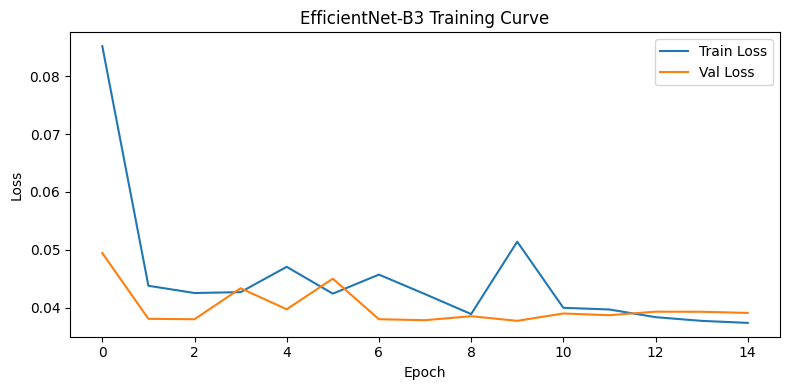

In [38]:
scaler = torch.cuda.amp.GradScaler()
CHECKPOINT_PATH = '/content/drive/MyDrive/efficientnet_best.pt'

best_val_loss  = float('inf')
patience       = 5
patience_count = 0
train_losses, val_losses = [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    for volume, label in train_loader:
        volume, label = volume.to(DEVICE), label.to(DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            output = model(volume)
            loss   = criterion(output, label)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

        # Clear cache every batch
        torch.cuda.empty_cache()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for volume, label in val_loader:
            volume, label = volume.to(DEVICE), label.to(DEVICE)
            with torch.cuda.amp.autocast():
                output = model(volume)
                loss   = criterion(output, label)
            val_loss += loss.item()
            torch.cuda.empty_cache()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss  = avg_val_loss
        patience_count = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  ✓ Best model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.title('EfficientNet-B3 Training Curve')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/efficientnet_training_curve.png', dpi=150)
plt.show()

In [39]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

all_probs  = []
all_preds  = []
all_labels = []

with torch.no_grad():
    for volume, label in test_loader:
        volume = volume.to(DEVICE)
        with torch.cuda.amp.autocast():
            logits = model(volume)
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs >= 0.5).astype(int)
        all_probs.append(probs[0])
        all_preds.append(preds[0])
        all_labels.append(label.numpy()[0])
        torch.cuda.empty_cache()

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"Test set: {len(all_labels)} patients")
print(f"Predictions shape: {all_preds.shape}")

Test set: 56 patients
Predictions shape: (56, 3)


CLASSIFICATION REPORT

Class: NCR
              precision    recall  f1-score   support

      No NCR       0.00      0.00      0.00         0
         NCR       1.00      1.00      1.00        56

    accuracy                           1.00        56
   macro avg       0.50      0.50      0.50        56
weighted avg       1.00      1.00      1.00        56


Class: ED
              precision    recall  f1-score   support

       No ED       0.00      0.00      0.00         0
          ED       1.00      1.00      1.00        56

    accuracy                           1.00        56
   macro avg       0.50      0.50      0.50        56
weighted avg       1.00      1.00      1.00        56


Class: ET
              precision    recall  f1-score   support

       No ET       0.05      1.00      0.10         3
          ET       0.00      0.00      0.00        53

    accuracy                           0.05        56
   macro avg       0.03      0.50      0.05        56
weighted avg      

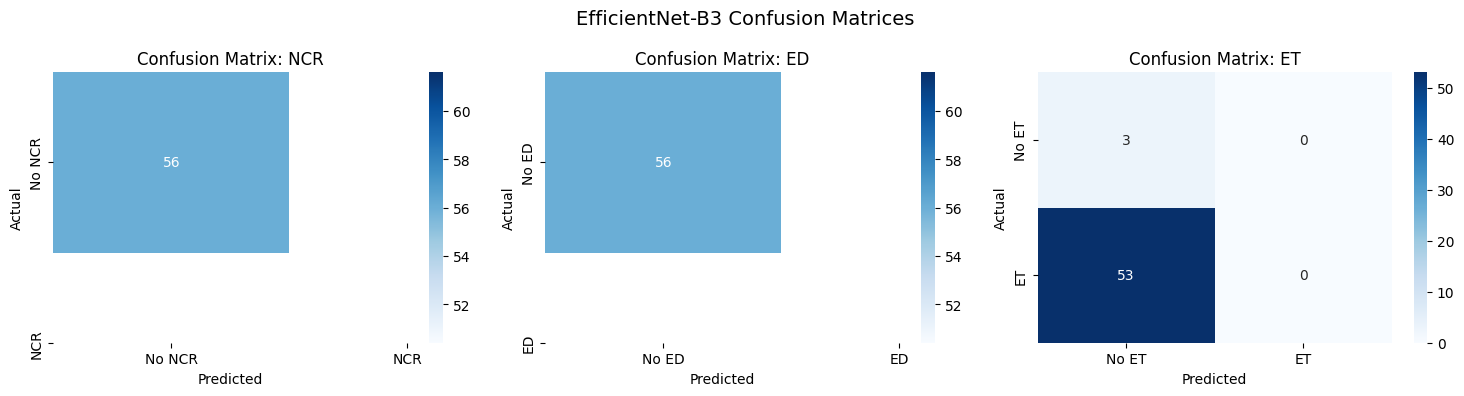


AUROC
  NCR: nan
  ED: nan
  ET: 0.6415
  Macro AUROC: 0.6415


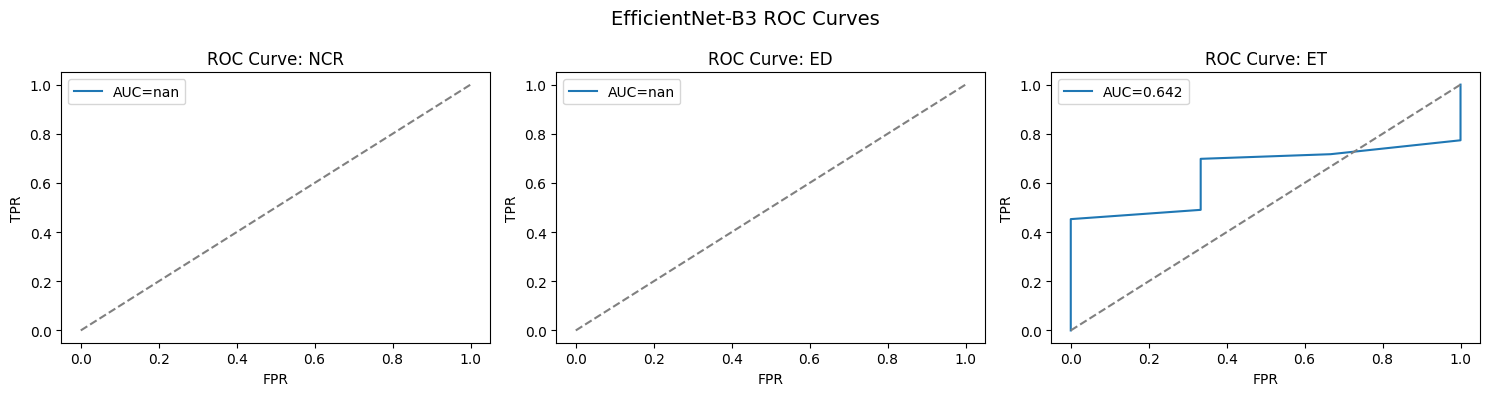

LOG LOSS
  NCR: 0.0866
  ED: 0.0799
  ET: 0.7663
  Mean Log Loss: 0.3109


In [42]:
CLASS_NAMES = ['NCR', 'ED', 'ET']

# ── 1. Classification Report ──────────────────────────────────────────────────
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
for i, cls in enumerate(CLASS_NAMES):
    print(f"\nClass: {cls}")
    print(classification_report(
        all_labels[:, i], all_preds[:, i],
        labels=[0, 1],
        target_names=[f'No {cls}', cls], zero_division=0
    ))

overall_acc = accuracy_score(all_labels.flatten(), all_preds.flatten())
print(f"Overall Flat Accuracy: {overall_acc:.4f}")

# ── 2. Confusion Matrix ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cls in enumerate(CLASS_NAMES):
    cm = confusion_matrix(all_labels[:, i], all_preds[:, i])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                xticklabels=[f'No {cls}', cls],
                yticklabels=[f'No {cls}', cls],
                cmap='Blues')
    axes[i].set_title(f'Confusion Matrix: {cls}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.suptitle('EfficientNet-B3 Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/efficientnet_confusion_matrices.png', dpi=150)
plt.show()

# ── 3. AUROC ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("AUROC")
print("=" * 60)
auroc_scores = {}
for i, cls in enumerate(CLASS_NAMES):
    try:
        score = roc_auc_score(all_labels[:, i], all_probs[:, i])
    except ValueError:
        score = float('nan')
    auroc_scores[cls] = score
    print(f"  {cls}: {score:.4f}")
print(f"  Macro AUROC: {np.nanmean(list(auroc_scores.values())):.4f}")

# ROC Curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    axes[i].plot(fpr, tpr, label=f'AUC={auroc_scores[cls]:.3f}')
    axes[i].plot([0,1],[0,1],'--', color='gray')
    axes[i].set_title(f'ROC Curve: {cls}')
    axes[i].set_xlabel('FPR')
    axes[i].set_ylabel('TPR')
    axes[i].legend()
plt.suptitle('EfficientNet-B3 ROC Curves', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/efficientnet_roc_curves.png', dpi=150)
plt.show()

# ── 4. Log Loss (fixed) ───────────────────────────────────────────────────────
print("=" * 60)
print("LOG LOSS")
print("=" * 60)
logloss_scores = {}
for i, cls in enumerate(CLASS_NAMES):
    try:
        ll = log_loss(all_labels[:, i], all_probs[:, i], labels=[0, 1])
        logloss_scores[cls] = ll
        print(f"  {cls}: {ll:.4f}")
    except Exception as e:
        logloss_scores[cls] = float('nan')
        print(f"  {cls}: N/A (only one class in test set)")
print(f"  Mean Log Loss: {np.nanmean(list(logloss_scores.values())):.4f}")

In [43]:
# Try different threshold for ET specifically
print("Threshold tuning for ET:")
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds_thresh = (all_probs[:, 2] >= thresh).astype(int)
    f1 = f1_score(all_labels[:, 2], preds_thresh, zero_division=0)
    recall = recall_score(all_labels[:, 2], preds_thresh, zero_division=0)
    precision = precision_score(all_labels[:, 2], preds_thresh, zero_division=0)
    print(f"  Thresh={thresh:.1f} | P={precision:.3f} R={recall:.3f} F1={f1:.3f}")

Threshold tuning for ET:
  Thresh=0.1 | P=0.946 R=1.000 F1=0.972
  Thresh=0.2 | P=0.946 R=1.000 F1=0.972
  Thresh=0.3 | P=0.946 R=1.000 F1=0.972
  Thresh=0.4 | P=0.946 R=1.000 F1=0.972
  Thresh=0.5 | P=0.000 R=0.000 F1=0.000
  Thresh=0.6 | P=0.000 R=0.000 F1=0.000
  Thresh=0.7 | P=0.000 R=0.000 F1=0.000
  Thresh=0.8 | P=0.000 R=0.000 F1=0.000
  Thresh=0.9 | P=0.000 R=0.000 F1=0.000


FINAL CLASSIFICATION REPORT (optimized thresholds)

Class: NCR (threshold=0.5)
              precision    recall  f1-score   support

      No NCR       0.00      0.00      0.00         0
         NCR       1.00      1.00      1.00        56

    accuracy                           1.00        56
   macro avg       0.50      0.50      0.50        56
weighted avg       1.00      1.00      1.00        56


Class: ED (threshold=0.5)
              precision    recall  f1-score   support

       No ED       0.00      0.00      0.00         0
          ED       1.00      1.00      1.00        56

    accuracy                           1.00        56
   macro avg       0.50      0.50      0.50        56
weighted avg       1.00      1.00      1.00        56


Class: ET (threshold=0.4)
              precision    recall  f1-score   support

       No ET       0.00      0.00      0.00         3
          ET       0.95      1.00      0.97        53

    accuracy                           0.95      

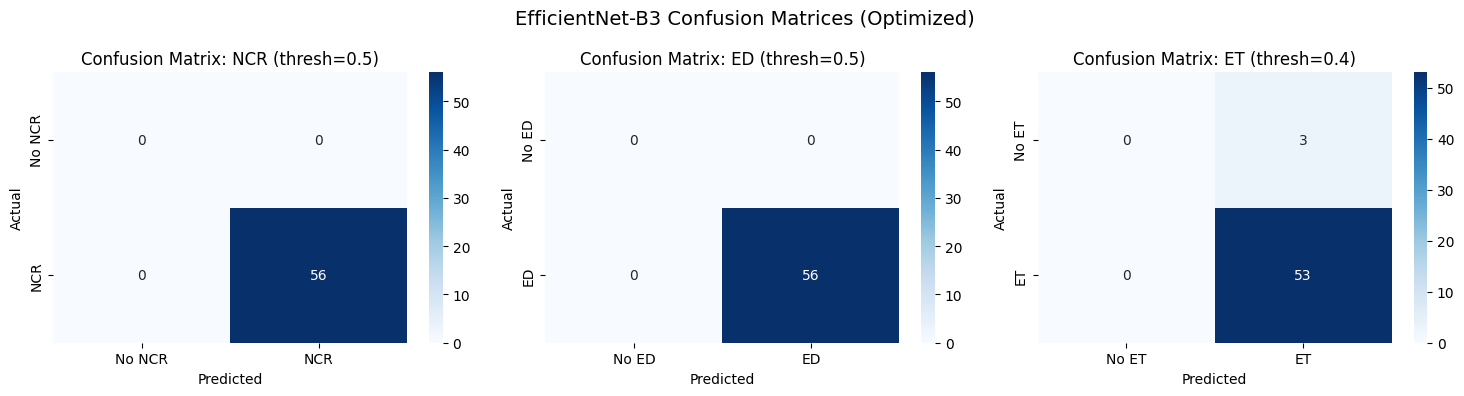


AUROC
  NCR: N/A (only one class in test set)
  ED: N/A (only one class in test set)
  ET: 0.6415
  Macro AUROC (ET only): 0.6415


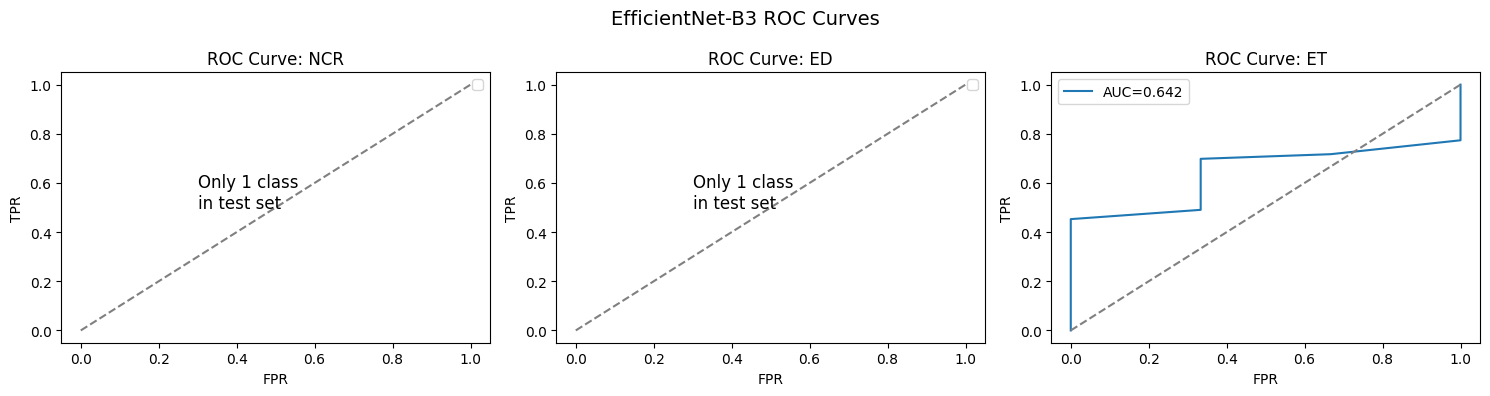


LOG LOSS
  NCR: 0.0866
  ED: 0.0799
  ET: 0.7663
  Mean Log Loss: 0.3109

✓ Final results saved to: /content/drive/MyDrive/efficientnet_results.json

FINAL SUMMARY:
  Accuracy:    0.9821
  Macro AUROC: 0.6415
  Mean LogLoss:0.3109
  NCR -> P:1.000 R:1.000 F1:1.000
  ED -> P:1.000 R:1.000 F1:1.000
  ET -> P:0.946 R:1.000 F1:0.972


In [44]:
# ── Final metrics with optimal thresholds ────────────────────────────────────
THRESHOLDS = {'NCR': 0.5, 'ED': 0.5, 'ET': 0.4}

# Recompute predictions with optimal thresholds
all_preds_final = np.zeros_like(all_preds)
for i, cls in enumerate(CLASS_NAMES):
    all_preds_final[:, i] = (all_probs[:, i] >= THRESHOLDS[cls]).astype(int)

# ── 1. Classification Report ──────────────────────────────────────────────────
print("=" * 60)
print("FINAL CLASSIFICATION REPORT (optimized thresholds)")
print("=" * 60)
for i, cls in enumerate(CLASS_NAMES):
    print(f"\nClass: {cls} (threshold={THRESHOLDS[cls]})")
    print(classification_report(
        all_labels[:, i], all_preds_final[:, i],
        labels=[0, 1],
        target_names=[f'No {cls}', cls], zero_division=0
    ))

overall_acc = accuracy_score(all_labels.flatten(), all_preds_final.flatten())
print(f"Overall Flat Accuracy: {overall_acc:.4f}")

# ── 2. Confusion Matrices ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cls in enumerate(CLASS_NAMES):
    cm = confusion_matrix(all_labels[:, i], all_preds_final[:, i], labels=[0,1])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                xticklabels=[f'No {cls}', cls],
                yticklabels=[f'No {cls}', cls],
                cmap='Blues')
    axes[i].set_title(f'Confusion Matrix: {cls} (thresh={THRESHOLDS[cls]})')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.suptitle('EfficientNet-B3 Confusion Matrices (Optimized)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/efficientnet_confusion_matrices_final.png', dpi=150)
plt.show()

# ── 3. AUROC ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("AUROC")
print("=" * 60)
auroc_scores = {}
for i, cls in enumerate(CLASS_NAMES):
    try:
        score = roc_auc_score(all_labels[:, i], all_probs[:, i])
    except ValueError:
        score = float('nan')
    auroc_scores[cls] = score
    print(f"  {cls}: {score:.4f}" if not np.isnan(score) else f"  {cls}: N/A (only one class in test set)")
print(f"  Macro AUROC (ET only): {np.nanmean(list(auroc_scores.values())):.4f}")

# ROC Curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cls in enumerate(CLASS_NAMES):
    if not np.isnan(auroc_scores[cls]):
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
        axes[i].plot(fpr, tpr, label=f'AUC={auroc_scores[cls]:.3f}')
    else:
        axes[i].text(0.3, 0.5, 'Only 1 class\nin test set', fontsize=12)
    axes[i].plot([0,1],[0,1],'--', color='gray')
    axes[i].set_title(f'ROC Curve: {cls}')
    axes[i].set_xlabel('FPR')
    axes[i].set_ylabel('TPR')
    axes[i].legend()
plt.suptitle('EfficientNet-B3 ROC Curves', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/efficientnet_roc_curves_final.png', dpi=150)
plt.show()

# ── 4. Log Loss ───────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("LOG LOSS")
print("=" * 60)
logloss_scores = {}
for i, cls in enumerate(CLASS_NAMES):
    try:
        ll = log_loss(all_labels[:, i], all_probs[:, i], labels=[0, 1])
        logloss_scores[cls] = ll
        print(f"  {cls}: {ll:.4f}")
    except Exception:
        logloss_scores[cls] = float('nan')
        print(f"  {cls}: N/A (only one class in test set)")
print(f"  Mean Log Loss: {np.nanmean(list(logloss_scores.values())):.4f}")

# ── 5. Save final results ─────────────────────────────────────────────────────
results = {
    'model': 'EfficientNet-B3 + Mean Pooling',
    'thresholds': THRESHOLDS,
    'accuracy': float(overall_acc),
    'auroc': {k: (float(v) if not np.isnan(v) else None) for k, v in auroc_scores.items()},
    'macro_auroc': float(np.nanmean(list(auroc_scores.values()))),
    'log_loss': {k: (float(v) if not np.isnan(v) else None) for k, v in logloss_scores.items()},
    'mean_log_loss': float(np.nanmean(list(logloss_scores.values()))),
    'all_probs':  all_probs.tolist(),
    'all_preds':  all_preds_final.tolist(),
    'all_labels': all_labels.tolist(),
    'per_class':  {}
}

for i, cls in enumerate(CLASS_NAMES):
    results['per_class'][cls] = {
        'precision': float(precision_score(all_labels[:,i], all_preds_final[:,i], zero_division=0)),
        'recall':    float(recall_score(all_labels[:,i],    all_preds_final[:,i], zero_division=0)),
        'f1':        float(f1_score(all_labels[:,i],        all_preds_final[:,i], zero_division=0)),
    }

results_path = '/content/drive/MyDrive/efficientnet_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✓ Final results saved to: {results_path}")
print("\nFINAL SUMMARY:")
print(f"  Accuracy:    {results['accuracy']:.4f}")
print(f"  Macro AUROC: {results['macro_auroc']:.4f}")
print(f"  Mean LogLoss:{results['mean_log_loss']:.4f}")
for cls in CLASS_NAMES:
    p = results['per_class'][cls]
    print(f"  {cls} -> P:{p['precision']:.3f} R:{p['recall']:.3f} F1:{p['f1']:.3f}")